# Correlación de Pearson: Visitas vs. Monto del Pedido

## 1. Contexto

El equipo de LMB observó que, en los meses con más quejas de clientes, también aumentan las devoluciones de producto. Concluyeron apresuradamente que **"las quejas causan las devoluciones"**. Sin embargo, ambas variables podrían estar siendo causadas por una **tercera variable** (variable de confusión): la calidad del producto entregado ese mes.

- Si la calidad baja → suben las quejas.
- Si la calidad baja → suben las devoluciones.
- Quejas y devoluciones se mueven juntas, pero **ninguna causa la otra directamente**.

Esto se conoce como **correlación espuria**: dos variables parecen relacionadas porque comparten una causa común, no porque exista una relación causal directa entre ellas.

Para reforzar el concepto de correlación (sin entrar en causalidad), se analiza a continuación un segundo caso: la relación entre las **visitas mensuales a un comercio** y el **monto del pedido**.

## 2. Tabla de interpretación del coeficiente r

| Valor de r | Interpretación |
|---|---|
| r = 1 | Correlación positiva perfecta: cuando una variable sube, la otra sube en la misma proporción |
| 0.7 a 0.99 | Correlación positiva fuerte |
| 0.3 a 0.69 | Correlación positiva moderada |
| 0.01 a 0.29 | Correlación positiva débil |
| 0 | No hay correlación lineal |
| -0.01 a -0.29 | Correlación negativa débil |
| -0.3 a -0.69 | Correlación negativa moderada |
| -0.7 a -0.99 | Correlación negativa fuerte |
| r = -1 | Correlación negativa perfecta: cuando una variable sube, la otra baja en la misma proporción |

## 3. Datos del caso: Visitas (X) vs. Monto del pedido en miles (Y)

| Comercio | Visitas en el mes (X) | Monto del pedido, en miles (Y) |
|----------|-----------------------|--------------------------------|
| MaxiPali | 2   | 45 |
|PriceSmart | 4 | 68 |
| MasxMenos | 1 | 30 |
| MegaSuper | 6 | 95 |
| Pali | 3 | 52 |
| Fresh Market | 5 | 80 |
| Cooperativas | 2 | 40 |

## 4. Fórmula del coeficiente de correlación de Pearson

$$r = \frac{n\sum XY - \sum X \sum Y}{\sqrt{[n\sum X^2 - (\sum X)^2][n\sum Y^2 - (\sum Y)^2]}}$$

## 5. Desarrollo en Python

### 5.1 Carga de datos y construcción de la tabla auxiliar

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Datos originales
data = {
    'Comercio': ['MaxiPali', 'PriceSmart', 'MasxMenos', 'MegaSuper', 'Pali', 'Fresh Market', 'Cooperativas'],
    'X': [2, 4, 1, 6, 3, 5, 2],
    'Y': [45, 68, 30, 95, 52, 80, 40]
}

df = pd.DataFrame(data)

# Columnas auxiliares requeridas por la fórmula de Pearson
df['XY'] = df['X'] * df['Y']
df['X2'] = df['X'] ** 2
df['Y2'] = df['Y'] ** 2

df

,Comercio,X,Y,XY,X2,Y2
0,MaxiPali,2,45,90,4,2025
1,PriceSmart,4,68,272,16,4624
2,MasxMenos,1,30,30,1,900
3,MegaSuper,6,95,570,36,9025
4,Pali,3,52,156,9,2704
5,Fresh Market,5,80,400,25,6400
6,Cooperativas,2,40,80,4,1600


In [2]:
# Fila de sumatorias
sumatorias = df[['X', 'Y', 'XY', 'X2', 'Y2']].sum()
print('Sumatorias:')
print(sumatorias)

Sumatorias:
X        23
Y       410
XY     1598
X2       95
Y2    27278
dtype: int64


### 5.2 Cálculo manual de r (aplicando la fórmula paso a paso)

In [3]:
n = len(df)
sum_x = df['X'].sum()
sum_y = df['Y'].sum()
sum_xy = df['XY'].sum()
sum_x2 = df['X2'].sum()
sum_y2 = df['Y2'].sum()

numerador = n * sum_xy - sum_x * sum_y
denominador = np.sqrt((n * sum_x2 - sum_x**2) * (n * sum_y2 - sum_y**2))

r_manual = numerador / denominador

print(f'n = {n}')
print(f'ΣX = {sum_x}, ΣY = {sum_y}, ΣXY = {sum_xy}, ΣX² = {sum_x2}, ΣY² = {sum_y2}')
print(f'Numerador = {numerador}')
print(f'Denominador = {denominador:.4f}')
print(f'r (cálculo manual) = {r_manual:.4f}')

n = 7
ΣX = 23, ΣY = 410, ΣXY = 1598, ΣX² = 95, ΣY² = 27278
Numerador = 1756
Denominador = 1762.6843
r (cálculo manual) = 0.9962


### 5.3 Verificación con funciones de librerías (pandas y numpy)

In [4]:
# Verificación con pandas
r_pandas = df['X'].corr(df['Y'])

# Verificación con numpy
r_numpy = np.corrcoef(df['X'], df['Y'])[0, 1]

print(f'r (pandas)  = {r_pandas:.4f}')
print(f'r (numpy)   = {r_numpy:.4f}')
print(f'r (manual)  = {r_manual:.4f}')

r (pandas)  = 0.9962
r (numpy)   = 0.9962
r (manual)  = 0.9962


### 5.4 Gráfico de dispersión con línea de tendencia

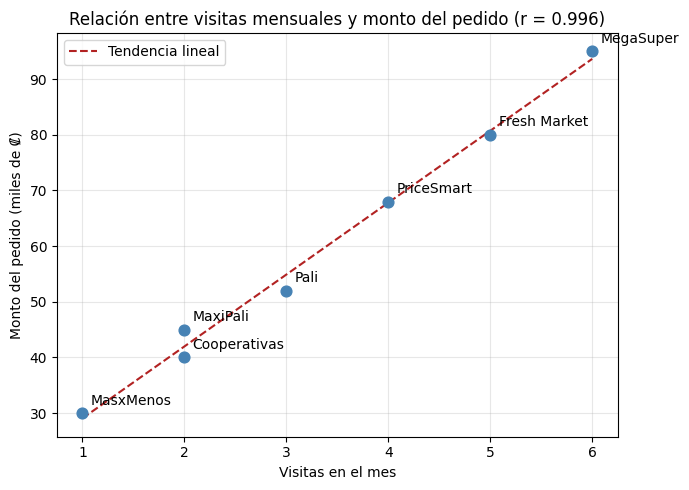

In [5]:
plt.figure(figsize=(7, 5))
plt.scatter(df['X'], df['Y'], color='steelblue', s=60, zorder=3)
for _, row in df.iterrows():
    plt.annotate(row['Comercio'], (row['X'], row['Y']), textcoords='offset points', xytext=(6, 6))

# Línea de tendencia
z = np.polyfit(df['X'], df['Y'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['X'].min(), df['X'].max(), 100)
plt.plot(x_line, p(x_line), color='firebrick', linestyle='--', label='Tendencia lineal')

plt.title(f'Relación entre visitas mensuales y monto del pedido (r = {r_manual:.3f})')
plt.xlabel('Visitas en el mes')
plt.ylabel('Monto del pedido (miles de ₡)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 5.5 Gráfico de líneas por Comercio (X y Y), con etiquetas de valor

Mismos datos, presentados como serie por comercio (eje X = comercio) para comparar visitas y monto del pedido, siguiendo el mismo estilo de `annotate` usado en el análisis de ventas por mes.

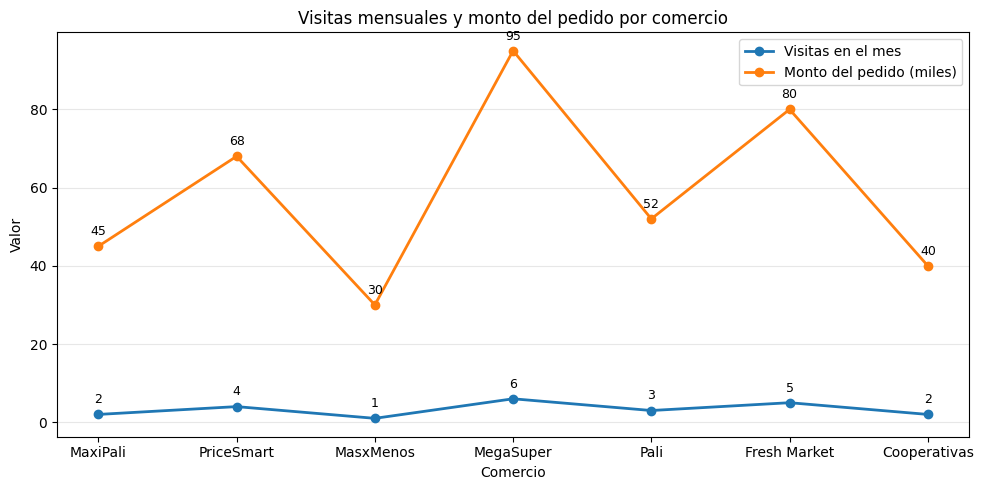

In [6]:
df_lineas = df.set_index('Comercio')[['X', 'Y']]

ax = df_lineas.plot(
    kind='line',
    figsize=(10, 5),
    marker='o',
    linewidth=2,
    color=['#1f77b4', '#ff7f0e']
)

plt.title('Visitas mensuales y monto del pedido por comercio')
plt.xlabel('Comercio')
plt.ylabel('Valor')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
ax.legend(['Visitas en el mes', 'Monto del pedido (miles)'])

# Etiquetas con el valor de cada punto
for columna in df_lineas.columns:
    for i, valor in enumerate(df_lineas[columna]):
        ax.annotate(str(valor), (i, valor), textcoords='offset points',
                    xytext=(0, 8), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

### 5.6 Gráfico de barras agrupadas por Comercio, con `bar_label`

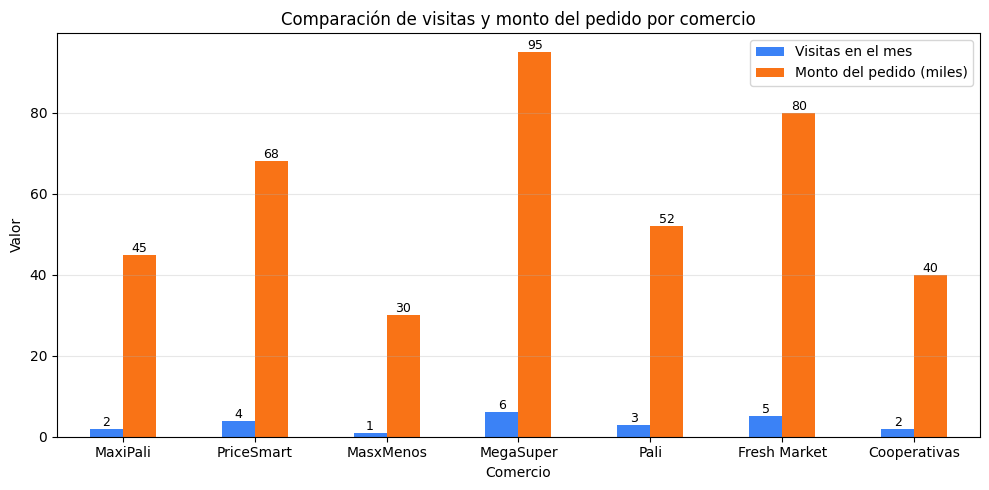

In [7]:
ax2 = df_lineas.plot(
    kind='bar',
    figsize=(10, 5),
    color=['#3B82F6', '#F97316']
)

plt.title('Comparación de visitas y monto del pedido por comercio')
plt.xlabel('Comercio')
plt.ylabel('Valor')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
ax2.legend(['Visitas en el mes', 'Monto del pedido (miles)'])

# Etiquetas con el valor de cada barra
for contenedor in ax2.containers:
    ax2.bar_label(contenedor, fontsize=9)

plt.tight_layout()
plt.show()

### 5.7 Visitas y Monto en un mismo gráfico con doble eje

Igual que en tu ejemplo (ventas + porcentaje en doble eje): aquí se combinan Visitas (eje izquierdo) y Monto del pedido (eje derecho) para ver ambas escalas en un solo gráfico.

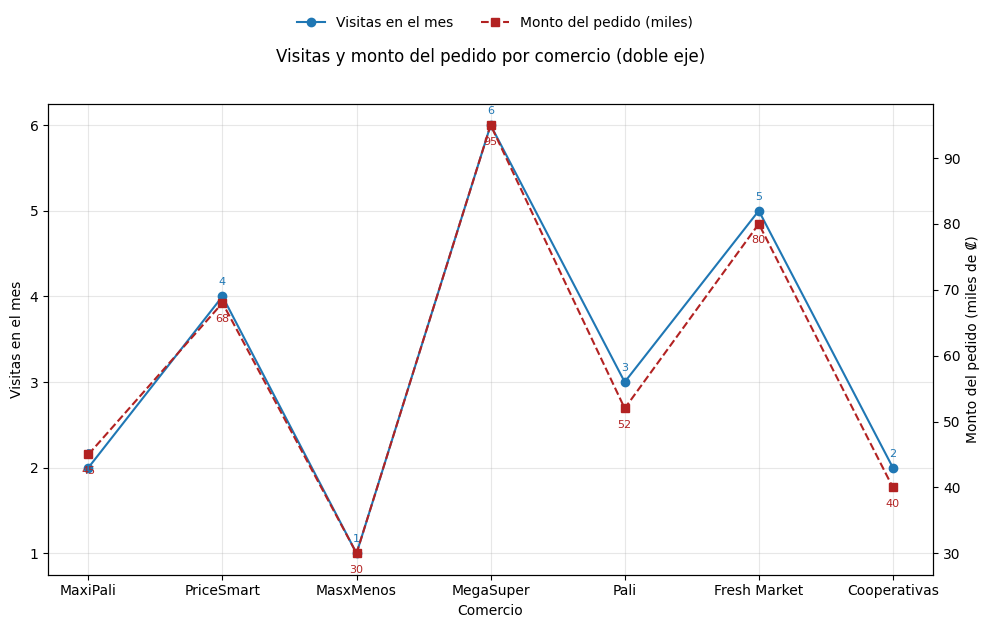

In [8]:
fig, ax1 = plt.subplots(figsize=(10, 6))

df_lineas['X'].plot(
    kind='line', marker='o', ax=ax1, color='#1f77b4', label='Visitas en el mes'
)
ax1.set_ylabel('Visitas en el mes')
ax1.set_xlabel('Comercio')
ax1.grid(True, alpha=0.3)

ax3 = ax1.twinx()
df_lineas['Y'].plot(
    kind='line', marker='s', linestyle='--', ax=ax3, color='firebrick', label='Monto del pedido (miles)'
)
ax3.set_ylabel('Monto del pedido (miles de ₡)')

# Etiquetas de valor en cada punto
for i, y in enumerate(df_lineas['X']):
    ax1.annotate(f'{y}', (i, y), textcoords='offset points', xytext=(0, 8),
                 ha='center', fontsize=8, color='#1f77b4')

for i, y in enumerate(df_lineas['Y']):
    ax3.annotate(f'{y}', (i, y), textcoords='offset points', xytext=(0, -14),
                 ha='center', fontsize=8, color='firebrick')

# Leyenda única, fuera del área de trazado
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax3.get_legend_handles_labels()
if ax1.get_legend(): ax1.get_legend().remove()
if ax3.get_legend(): ax3.get_legend().remove()

fig.legend(lines1 + lines2, labels1 + labels2,
           loc='upper center', bbox_to_anchor=(0.5, 1.05),
           ncol=2, frameon=False)

plt.title('Visitas y monto del pedido por comercio (doble eje)', pad=30)
plt.xticks(rotation=0)
fig.tight_layout()
plt.show()

### 5.8 Gráfico circular (pastel) de la distribución del Monto del pedido por Comercio

Usando la sintaxis proporcionada, adaptada a los nombres de columnas de este DataFrame (`Y` = Monto del pedido).

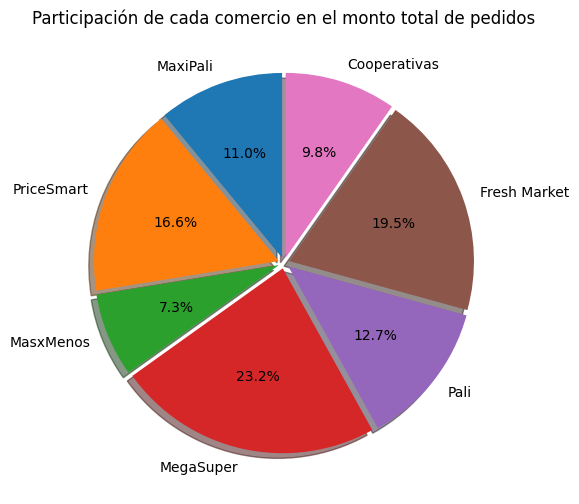

In [9]:
plt.figure(figsize=(6, 6))
plt.pie(
    df["Y"],
    labels=df["Comercio"],
    autopct="%1.1f%%",
    startangle=90,
    explode=[0.03] * len(df),
    shadow=True
)
plt.title("Participación de cada comercio en el monto total de pedidos")
plt.show()

## 6. Interpretación de resultados

El coeficiente obtenido es **r ≈ 0.996**, lo cual, según la tabla de interpretación, corresponde a una **correlación positiva fuerte** (rango 0.7 a 0.99, muy cercana a la correlación perfecta).

Esto indica que, a mayor número de visitas mensuales a un comercio, mayor tiende a ser el monto del pedido, con muy poca dispersión respecto a esa tendencia lineal. Las gráficas de líneas y barras por comercio muestran cómo ambas variables suben de forma paralela (D y F, con más visitas, tienen también los montos más altos; C, con solo 1 visita, tiene el monto más bajo).

**Nota importante — correlación no implica causalidad:** al igual que en el caso de LMB (quejas y devoluciones), un valor de r alto solo confirma la fuerza y dirección de la relación lineal entre las variables, no prueba por sí solo una relación causa-efecto. En este caso el vínculo causal es razonable desde el punto de vista de negocio (más visitas generan más oportunidades de compra), pero estadísticamente debe evaluarse con cautela, considerando siempre la posibilidad de variables de confusión.

## 7. Menú interactivo — seleccionar una tabla o gráfica por número

Ejecutá esta celda **después** de correr todas las celdas anteriores del notebook. Permite volver a mostrar, bajo demanda, cualquier tabla o gráfica ya generada, escribiendo el número correspondiente.


 MENÚ — Correlación de Pearson: Visitas vs. Monto del Pedido
 1. Tabla de datos con columnas auxiliares (X, Y, XY, X², Y²)
 2. Tabla de sumatorias (ΣX, ΣY, ΣXY, ΣX², ΣY²)
 3. Cálculo manual de r, paso a paso
 4. Verificación de r con pandas y numpy
 5. Gráfico de dispersión con línea de tendencia
 6. Gráfico de líneas por comercio (Visitas y Monto)
 7. Gráfico de barras agrupadas por comercio
 8. Gráfico de doble eje (Visitas vs. Monto)
 9. Gráfico circular (pastel) del monto por comercio
10. Interpretación final de resultados
 0. Salir del menú

-----------------------------------------------------------------
📌 Gráfico de dispersión con línea de tendencia
-----------------------------------------------------------------
Cada punto es un comercio según sus Visitas (X) y su Monto del
pedido (Y). La línea punteada es la recta de tendencia ajustada por
mínimos cuadrados. Mientras más pegados estén los puntos a la línea,
más fuerte es la correlación lineal (coherente con r ≈ 0.996).



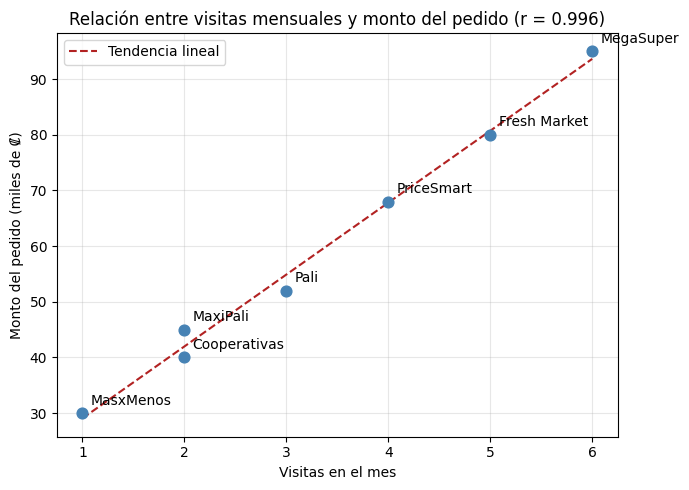


 MENÚ — Correlación de Pearson: Visitas vs. Monto del Pedido
 1. Tabla de datos con columnas auxiliares (X, Y, XY, X², Y²)
 2. Tabla de sumatorias (ΣX, ΣY, ΣXY, ΣX², ΣY²)
 3. Cálculo manual de r, paso a paso
 4. Verificación de r con pandas y numpy
 5. Gráfico de dispersión con línea de tendencia
 6. Gráfico de líneas por comercio (Visitas y Monto)
 7. Gráfico de barras agrupadas por comercio
 8. Gráfico de doble eje (Visitas vs. Monto)
 9. Gráfico circular (pastel) del monto por comercio
10. Interpretación final de resultados
 0. Salir del menú

-----------------------------------------------------------------
📌 Gráfico de líneas por comercio
-----------------------------------------------------------------
Compara Visitas y Monto del pedido, comercio por comercio (eje X),
como dos líneas con marcadores y el valor exacto anotado sobre cada
punto. Útil para ver visualmente si ambas variables 'se mueven
juntas' de un comercio a otro.



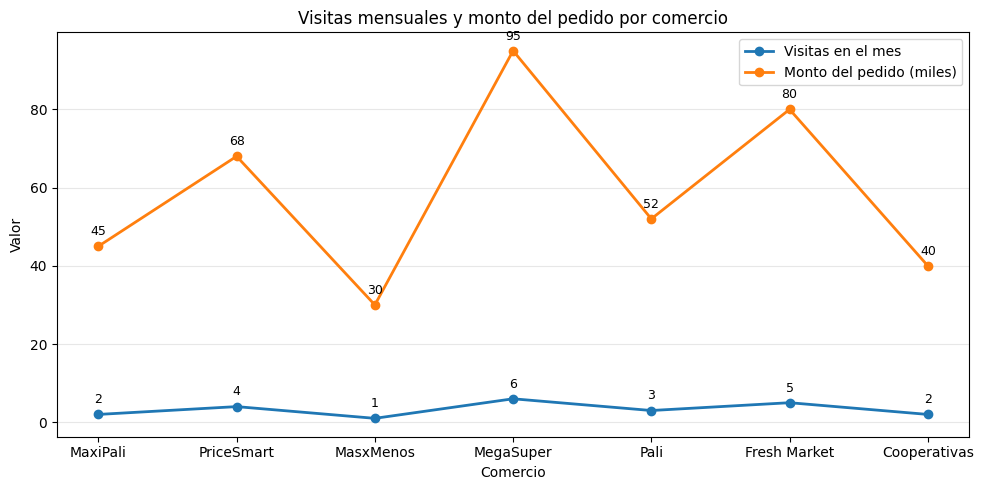


 MENÚ — Correlación de Pearson: Visitas vs. Monto del Pedido
 1. Tabla de datos con columnas auxiliares (X, Y, XY, X², Y²)
 2. Tabla de sumatorias (ΣX, ΣY, ΣXY, ΣX², ΣY²)
 3. Cálculo manual de r, paso a paso
 4. Verificación de r con pandas y numpy
 5. Gráfico de dispersión con línea de tendencia
 6. Gráfico de líneas por comercio (Visitas y Monto)
 7. Gráfico de barras agrupadas por comercio
 8. Gráfico de doble eje (Visitas vs. Monto)
 9. Gráfico circular (pastel) del monto por comercio
10. Interpretación final de resultados
 0. Salir del menú


In [ ]:
# ==========================================================================
# MENÚ INTERACTIVO — seleccionar una tabla o gráfica por número
# ==========================================================================
# IMPORTANTE: ejecutar esta celda DESPUÉS de correr todas las celdas
# anteriores del notebook. El menú no vuelve a calcular nada desde cero:
# reutiliza las variables ya creadas arriba (df, r_manual, r_pandas,
# r_numpy, n, sum_x, sum_y, etc.) para volver a mostrar, bajo demanda,
# cualquier tabla o gráfica ya generada, sin tener que desplazarse por
# todo el notebook cada vez.



from IPython.display import display

def _explicar(titulo, texto):
    """Imprime un encabezado y una explicación detallada antes de mostrar
    la tabla o gráfica correspondiente a la opción elegida."""
    print("\n" + "-" * 65)
    print(f"📌 {titulo}")
    print("-" * 65)
    print(texto)
    print()

def menu_pearson():
    intentos_invalidos = 0
    MAX_INTENTOS = 5  # corta el bucle si algo anda mal (ej. input vacío repetido)

    while True:
        print("\n" + "=" * 65)
        print(" MENÚ — Correlación de Pearson: Visitas vs. Monto del Pedido")
        print("=" * 65)
        print(""" 1. Tabla de datos con columnas auxiliares (X, Y, XY, X², Y²)
 2. Tabla de sumatorias (ΣX, ΣY, ΣXY, ΣX², ΣY²)
 3. Cálculo manual de r, paso a paso
 4. Verificación de r con pandas y numpy
 5. Gráfico de dispersión con línea de tendencia
 6. Gráfico de líneas por comercio (Visitas y Monto)
 7. Gráfico de barras agrupadas por comercio
 8. Gráfico de doble eje (Visitas vs. Monto)
 9. Gráfico circular (pastel) del monto por comercio
10. Interpretación final de resultados
 0. Salir del menú""")

        try:
            eleccion = input("\nElegí un número de opción: ").strip()
        except EOFError:
            # No hay forma de escribir input (ej. ejecución no interactiva) -> salir en vez de trabarse
            print("\n⚠️  No se recibió entrada (¿se ejecutó sin modo interactivo?). Saliendo del menú.")
            break

        if eleccion == "":
            intentos_invalidos += 1
            print("⚠️  No escribiste nada. Ingresá un número entre 0 y 10.")
            if intentos_invalidos >= MAX_INTENTOS:
                print("⚠️  Demasiados intentos vacíos seguidos. Saliendo del menú.")
                break
            continue

        intentos_invalidos = 0  # se resetea al recibir algo no vacío
        if eleccion == "1":
            # Esta tabla es el punto de partida de todo el análisis: junto a los
            # datos originales (Comercio, Visitas=X, Monto=Y) incluye las tres
            # columnas que exige la fórmula de Pearson (XY, X², Y²). Sin estas
            # columnas no se pueden obtener las sumatorias que la fórmula necesita,
            # así que revisar esta tabla es el primer paso para detectar errores
            # de captura antes de calcular cualquier estadístico.
            _explicar(
                "Tabla de datos con columnas auxiliares",
                "Datos originales (Comercio, Visitas=X, Monto del pedido=Y) más las\n"
                "columnas XY, X² y Y² que exige la fórmula de Pearson. Son la base de\n"
                "todos los cálculos posteriores: sin ellas no se pueden obtener las\n"
                "sumatorias (ΣXY, ΣX², ΣY²) que la fórmula necesita."
            )
            display(df)

        elif eleccion == "2":
            # Sumar cada columna por separado da directamente ΣX, ΣY, ΣXY, ΣX² y
            # ΣY², que son los cinco números que se insertan en el numerador y el
            # denominador de la fórmula de Pearson. Ver esta fila de sumatorias por
            # separado permite verificar, antes de calcular r, que ningún valor
            # quedó mal sumado o mal capturado.
            _explicar(
                "Tabla de sumatorias",
                "Suma cada columna (X, Y, XY, X², Y²) por separado. Estas cinco\n"
                "sumatorias son el insumo directo del numerador y denominador de la\n"
                "fórmula de Pearson; revisarlas por separado ayuda a detectar errores\n"
                "de captura antes de calcular r."
            )
            print(df[['X', 'Y', 'XY', 'X2', 'Y2']].sum())

        elif eleccion == "3":
            # Aplica la fórmula de Pearson tal cual, en cuatro pasos: arma el
            # numerador (n·ΣXY − ΣX·ΣY), arma el denominador (raíz cuadrada del
            # producto de dos diferencias de cuadrados) y divide uno entre otro
            # para obtener r. Este resultado "a mano" es el que se contrasta en la
            # siguiente opción contra las funciones de pandas y numpy.
            _explicar(
                "Cálculo manual de r (paso a paso)",
                "Aplica la fórmula de Pearson sobre las sumatorias: numerador =\n"
                "n·ΣXY − ΣX·ΣY; denominador = √[(n·ΣX² − (ΣX)²)·(n·ΣY² − (ΣY)²)];\n"
                "r = numerador / denominador. Este valor 'a mano' se contrasta en la\n"
                "opción 4 contra pandas y numpy."
            )
            print(f'n = {n}')
            print(f'ΣX = {sum_x}, ΣY = {sum_y}, ΣXY = {sum_xy}, ΣX² = {sum_x2}, ΣY² = {sum_y2}')
            print(f'Numerador = {numerador}')
            print(f'Denominador = {denominador:.4f}')
            print(f'r (cálculo manual) = {r_manual:.4f}')

        elif eleccion == "4":
            # Recalcula r con dos funciones ya integradas (df['X'].corr(df['Y']) de
            # pandas y np.corrcoef de numpy) y lo compara contra el r calculado a
            # mano en la opción 3. Si los tres valores coinciden (hasta el
            # redondeo), se confirma que la fórmula se aplicó correctamente.
            _explicar(
                "Verificación con pandas y numpy",
                "Recalcula r con funciones ya integradas (pandas .corr() y\n"
                "numpy.corrcoef) y lo compara contra el r_manual de la opción 3.\n"
                "Sirve de control de calidad: si coinciden, el cálculo manual fue\n"
                "correcto."
            )
            print(f'r (pandas)  = {r_pandas:.4f}')
            print(f'r (numpy)   = {r_numpy:.4f}')
            print(f'r (manual)  = {r_manual:.4f}')

        elif eleccion == "5":
            # Cada punto es un comercio ubicado según sus Visitas (X) y su Monto
            # del pedido (Y); la línea punteada roja es la recta de tendencia
            # ajustada por mínimos cuadrados (np.polyfit). Cuanto más pegados estén
            # los puntos a esa línea, más fuerte es la correlación lineal, algo
            # coherente con el r ≈ 0.996 obtenido en las opciones 3 y 4.
            _explicar(
                "Gráfico de dispersión con línea de tendencia",
                "Cada punto es un comercio según sus Visitas (X) y su Monto del\n"
                "pedido (Y). La línea punteada es la recta de tendencia ajustada por\n"
                "mínimos cuadrados. Mientras más pegados estén los puntos a la línea,\n"
                "más fuerte es la correlación lineal (coherente con r ≈ 0.996)."
            )
            plt.figure(figsize=(7, 5))
            plt.scatter(df['X'], df['Y'], color='steelblue', s=60, zorder=3)
            for _, row in df.iterrows():
                plt.annotate(row['Comercio'], (row['X'], row['Y']), textcoords='offset points', xytext=(6, 6))
            z = np.polyfit(df['X'], df['Y'], 1)
            p = np.poly1d(z)
            x_line = np.linspace(df['X'].min(), df['X'].max(), 100)
            plt.plot(x_line, p(x_line), color='firebrick', linestyle='--', label='Tendencia lineal')
            plt.title(f'Relación entre visitas mensuales y monto del pedido (r = {r_manual:.3f})')
            plt.xlabel('Visitas en el mes')
            plt.ylabel('Monto del pedido (miles de ₡)')
            plt.legend()
            plt.grid(alpha=0.3)
            plt.tight_layout()
            plt.show()

        elif eleccion == "6":
            # Presenta las dos variables originales (Visitas y Monto) como series
            # de líneas, una por comercio en el eje X, con el valor exacto anotado
            # sobre cada punto. Sirve para ver, de forma visual y sin depender de
            # una sola escala, si ambas series suben y bajan juntas entre comercios.
            _explicar(
                "Gráfico de líneas por comercio",
                "Compara Visitas y Monto del pedido, comercio por comercio (eje X),\n"
                "como dos líneas con marcadores y el valor exacto anotado sobre cada\n"
                "punto. Útil para ver visualmente si ambas variables 'se mueven\n"
                "juntas' de un comercio a otro."
            )
            df_lineas_ = df.set_index('Comercio')[['X', 'Y']]
            ax = df_lineas_.plot(kind='line', figsize=(10, 5), marker='o', linewidth=2, color=['#1f77b4', '#ff7f0e'])
            plt.title('Visitas mensuales y monto del pedido por comercio')
            plt.xlabel('Comercio')
            plt.ylabel('Valor')
            plt.xticks(rotation=0)
            plt.grid(axis='y', alpha=0.3)
            ax.legend(['Visitas en el mes', 'Monto del pedido (miles)'])
            for columna in df_lineas_.columns:
                for i, valor in enumerate(df_lineas_[columna]):
                    ax.annotate(str(valor), (i, valor), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=9)
            plt.tight_layout()
            plt.show()

        elif eleccion == "7":
            # Misma comparación de Visitas vs. Monto por comercio que la opción 6,
            # pero en formato de barras agrupadas con el valor exacto impreso sobre
            # cada barra (bar_label). Las barras facilitan comparar magnitudes
            # puntuales entre comercios, mientras que las líneas resaltan mejor la
            # tendencia general entre comercios consecutivos.
            _explicar(
                "Gráfico de barras agrupadas por comercio",
                "Misma comparación Visitas vs. Monto por comercio que la opción 6,\n"
                "pero en barras agrupadas con el valor exacto sobre cada barra. Las\n"
                "barras facilitan comparar magnitudes puntuales entre comercios."
            )
            df_lineas_ = df.set_index('Comercio')[['X', 'Y']]
            ax2 = df_lineas_.plot(kind='bar', figsize=(10, 5), color=['#3B82F6', '#F97316'])
            plt.title('Comparación de visitas y monto del pedido por comercio')
            plt.xlabel('Comercio')
            plt.ylabel('Valor')
            plt.xticks(rotation=0)
            plt.grid(axis='y', alpha=0.3)
            ax2.legend(['Visitas en el mes', 'Monto del pedido (miles)'])
            for contenedor in ax2.containers:
                ax2.bar_label(contenedor, fontsize=9)
            plt.tight_layout()
            plt.show()

        elif eleccion == "8":
            # Combina Visitas (eje izquierdo, azul) y Monto (eje derecho, rojo) en
            # un mismo gráfico con dos escalas distintas. Es útil porque las dos
            # variables tienen rangos numéricos muy diferentes (Visitas 1 a 6,
            # Monto 30 a 95) y así se ve su forma conjunta sin que la escala más
            # grande "aplaste" visualmente a la más chica.
            _explicar(
                "Gráfico de doble eje",
                "Combina Visitas (eje izquierdo) y Monto (eje derecho) en un mismo\n"
                "gráfico con dos escalas distintas. Útil cuando las variables tienen\n"
                "rangos numéricos muy diferentes, para que ninguna 'aplaste' a la otra\n"
                "visualmente."
            )
            df_lineas_ = df.set_index('Comercio')[['X', 'Y']]
            fig, ax1 = plt.subplots(figsize=(10, 6))
            df_lineas_['X'].plot(kind='line', marker='o', ax=ax1, color='#1f77b4', label='Visitas en el mes')
            ax1.set_ylabel('Visitas en el mes')
            ax1.set_xlabel('Comercio')
            ax1.grid(True, alpha=0.3)
            ax3 = ax1.twinx()
            df_lineas_['Y'].plot(kind='line', marker='s', linestyle='--', ax=ax3, color='firebrick', label='Monto del pedido (miles)')
            ax3.set_ylabel('Monto del pedido (miles de ₡)')
            for i, y in enumerate(df_lineas_['X']):
                ax1.annotate(f'{y}', (i, y), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8, color='#1f77b4')
            for i, y in enumerate(df_lineas_['Y']):
                ax3.annotate(f'{y}', (i, y), textcoords='offset points', xytext=(0, -14), ha='center', fontsize=8, color='firebrick')
            lines1, labels1 = ax1.get_legend_handles_labels()
            lines2, labels2 = ax3.get_legend_handles_labels()
            if ax1.get_legend(): ax1.get_legend().remove()
            if ax3.get_legend(): ax3.get_legend().remove()
            fig.legend(lines1 + lines2, labels1 + labels2, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=2, frameon=False)
            plt.title('Visitas y monto del pedido por comercio (doble eje)', pad=30)
            plt.xticks(rotation=0)
            fig.tight_layout()
            plt.show()

        elif eleccion == "9":
            # Muestra qué porcentaje del monto total de pedidos aporta cada
            # comercio. No mide correlación por sí sola, pero complementa el
            # análisis: permite ver de un vistazo qué tanto "pesa" cada comercio
            # dentro del total, coherente con los comercios que ya se vieron con
            # más visitas y monto en los gráficos anteriores.
            _explicar(
                "Gráfico circular (pastel)",
                "Muestra el porcentaje del monto total de pedidos que aporta cada\n"
                "comercio. No mide correlación por sí sola, pero complementa el\n"
                "análisis mostrando qué tanto 'pesa' cada comercio dentro del total."
            )
            plt.figure(figsize=(6, 6))
            plt.pie(df["Y"], labels=df["Comercio"], autopct="%1.1f%%", startangle=90,
                    explode=[0.03] * len(df), shadow=True)
            plt.title("Participación de cada comercio en el monto total de pedidos")
            plt.show()

        elif eleccion == "10":
            # Resume, en lenguaje de negocio, qué significa el valor de r obtenido
            # según la tabla de interpretación de la sección 2, y repite la
            # advertencia central del notebook: correlación no implica causalidad,
            # por analogía con el caso de quejas vs. devoluciones de LMB.
            _explicar(
                "Interpretación final de resultados",
                "Traduce el valor de r obtenido a la tabla de interpretación de la\n"
                "sección 2, y recuerda la advertencia central del notebook:\n"
                "correlación no implica causalidad."
            )
            print(f"r ≈ {r_manual:.3f} → según la tabla de interpretación, corresponde a una")
            print("correlación positiva fuerte (rango 0.7 a 0.99, muy cercana a la correlación perfecta).")
            print()
            print("A mayor número de visitas mensuales a un comercio, mayor tiende a ser el monto del")
            print("pedido, con muy poca dispersión respecto a esa tendencia lineal.")
            print()
            print("Nota importante — correlación no implica causalidad: un r alto solo confirma la")
            print("fuerza y dirección de la relación lineal, no prueba por sí solo una relación")
            print("causa-efecto (recordar el caso de quejas vs. devoluciones de LMB en la sección 1).")

        elif eleccion == "0":
            print("Saliendo del menú.")
            break

        else:
            print("⚠️  Opción no válida. Elegí un número entre 0 y 10.")

menu_pearson()
